In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [ ]:
df=pd.read_csv('cleanwelddata_filled_ssl.csv')

In [ ]:
features = ["Yield strength (MPa)","Reduction of Area (%)","Elongation (%)" ,"Ultimate tensile strength (MPa)"]

X = df[features]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# On teste K-means

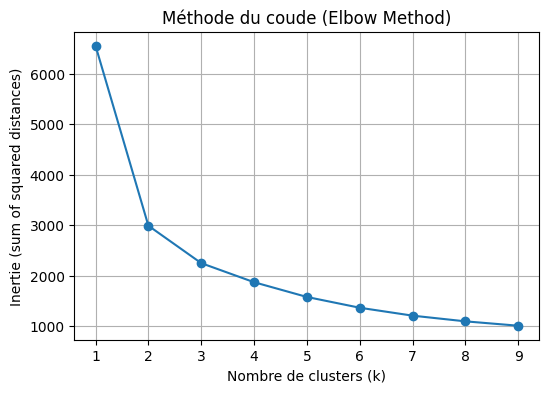

In [ ]:
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (sum of squared distances)")
plt.title("Méthode du coude (Elbow Method)")
plt.grid(True)
plt.show()


In [ ]:
k_optimal = 4
kmeans = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=10,
    random_state=42
)
kmeans.fit(X_scaled)

labels = kmeans.labels_

df_clusters = X.copy()
df_clusters["cluster"] = labels

df_clusters.head()


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),cluster
0,392.000000,80.600000,31.900000,466.000000,1
1,389.621704,80.177002,33.847198,469.341492,1
2,370.000000,80.600000,35.200000,456.000000,1
3,413.000000,80.600000,31.200000,498.000000,1
4,416.176819,80.045105,32.911324,493.187958,1


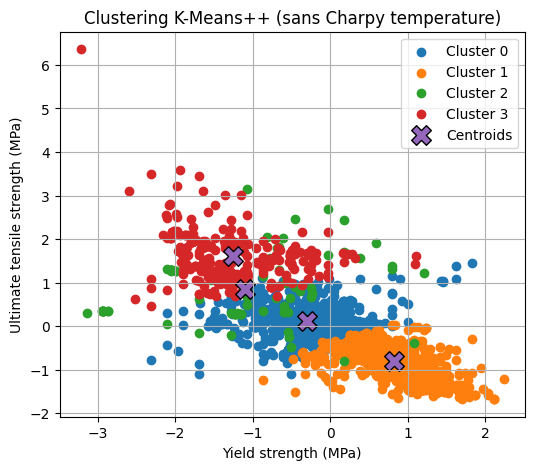

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_idx = features.index("Elongation (%)")
y_idx = features.index("Ultimate tensile strength (MPa)")

plt.figure(figsize=(6, 5))

for cluster_id in range(k_optimal):
    cluster_points = X_scaled[labels == cluster_id]
    plt.scatter(
        cluster_points[:, x_idx],
        cluster_points[:, y_idx],
        label=f"Cluster {cluster_id}"
    )

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, x_idx],
    centers[:, y_idx],
    s=200,
    marker="X",
    edgecolor="black",
    label="Centroids"
)

plt.xlabel("Yield strength (MPa)")
plt.ylabel("Ultimate tensile strength (MPa)")
plt.title("Clustering K-Means++ (sans Charpy temperature)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)


(1639, 4)


# On teste avec GMM (gaussian Mixure)

Histoire de avoir des distribustion et des proba en  retour

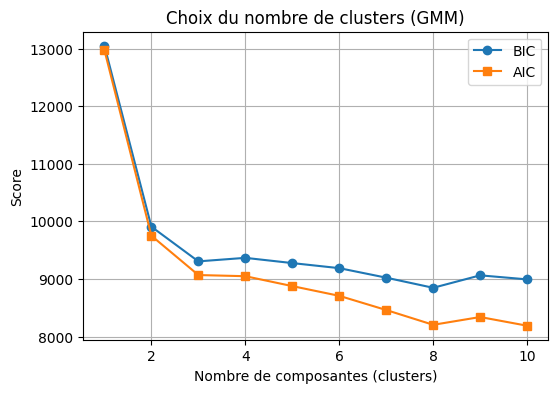

In [ ]:
n_components_range = range(1, 11)
bics = []
aics = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.figure(figsize=(6, 4))
plt.plot(n_components_range, bics, marker="o", label="BIC")
plt.plot(n_components_range, aics, marker="s", label="AIC")
plt.xlabel("Nombre de composantes (clusters)")
plt.ylabel("Score")
plt.title("Choix du nombre de clusters (GMM)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
n_optimal = 3
gmm = GaussianMixture(
    n_components=n_optimal,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_scaled)

# labels (cluster le plus probable)
labels_gmm = gmm.predict(X_scaled)

# Probabilités d'appartenance à chaque cluster
probas = gmm.predict_proba(X_scaled)

df_gmm = X.copy()
df_gmm["cluster_gmm"] = labels_gmm

df_gmm.head()


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),cluster_gmm
0,392.000000,80.600000,31.900000,466.000000,0
1,389.621704,80.177002,33.847198,469.341492,0
2,370.000000,80.600000,35.200000,456.000000,0
3,413.000000,80.600000,31.200000,498.000000,0
4,416.176819,80.045105,32.911324,493.187958,0


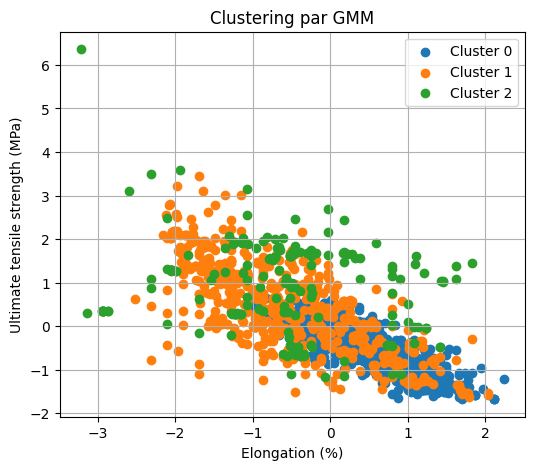

In [ ]:
x_idx = features.index("Elongation (%)")
y_idx = features.index("Ultimate tensile strength (MPa)")

plt.figure(figsize=(6, 5))
for c in range(n_optimal):
    pts = X_scaled[labels_gmm == c]
    plt.scatter(pts[:, x_idx], pts[:, y_idx], label=f"Cluster {c}")

plt.xlabel("Elongation (%)")
plt.ylabel("Ultimate tensile strength (MPa)")
plt.title("Clustering par GMM")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.mixture import GaussianMixture

n_optimal = 3

gmm = GaussianMixture(
    n_components=n_optimal,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)
probas_gmm = gmm.predict_proba(X_scaled)

df_gmm = X.copy()
df_gmm["cluster_gmm"] = labels_gmm

df_gmm.head()


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),cluster_gmm
0,392.000000,80.600000,31.900000,466.000000,0
1,389.621704,80.177002,33.847198,469.341492,0
2,370.000000,80.600000,35.200000,456.000000,0
3,413.000000,80.600000,31.200000,498.000000,0
4,416.176819,80.045105,32.911324,493.187958,0


In [ ]:
cluster_counts = df_gmm["cluster_gmm"].value_counts().sort_index()
print(cluster_counts)


cluster_gmm
0    840
1    612
2    187
Name: count, dtype: int64


In [ ]:
cluster_means = df_gmm.groupby("cluster_gmm")[features].mean()
print(cluster_means)


             Yield strength (MPa)  Reduction of Area (%)  Elongation (%)  \
cluster_gmm                                                                
0                      457.766891              77.608980       29.057794   
1                      541.777655              67.871922       23.088912   
2                      566.549298              55.713992       23.220578   

             Ultimate tensile strength (MPa)  
cluster_gmm                                   
0                                 542.312860  
1                                 639.604559  
2                                 675.812404  


In [ ]:
cluster_stats = df_gmm.groupby("cluster_gmm")[features].agg(["mean", "std"])
cluster_stats


Yield strength (MPa)            Reduction of Area (%)             \
                            mean        std                  mean        std   
cluster_gmm                                                                    
0                     457.766891  48.518715             77.608980   1.735225   
1                     541.777655  96.231267             67.871922   4.754702   
2                     566.549298  99.925893             55.713992  12.244882   

            Elongation (%)           Ultimate tensile strength (MPa)  \
                      mean       std                            mean   
cluster_gmm                                                            
0                29.057794  2.759228                      542.312860   
1                23.088912  4.506719                      639.604559   
2                23.220578  5.283907                      675.812404   

                        
                   std  
cluster_gmm             
0            43.149591  
1            87.675441  
2            91.117480

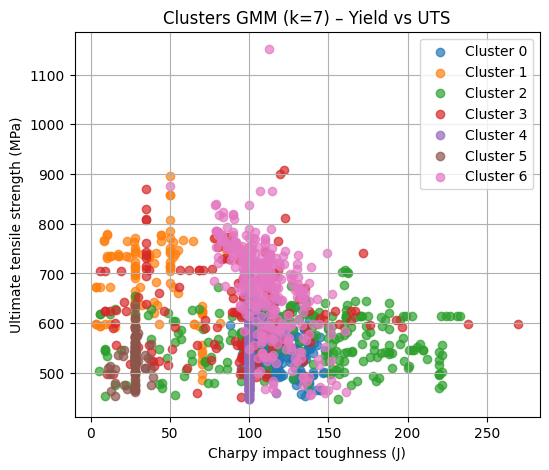

In [ ]:
import matplotlib.pyplot as plt

x_feat = "Charpy impact toughness (J)"
y_feat = "Ultimate tensile strength (MPa)"

plt.figure(figsize=(6, 5))
for c in range(n_optimal):
    subset = df_gmm[df_gmm["cluster_gmm"] == c]
    plt.scatter(
        subset[x_feat],
        subset[y_feat],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel(x_feat)
plt.ylabel(y_feat)
plt.title("Clusters GMM (k=7) – Yield vs UTS")
plt.legend()
plt.grid(True)
plt.show()


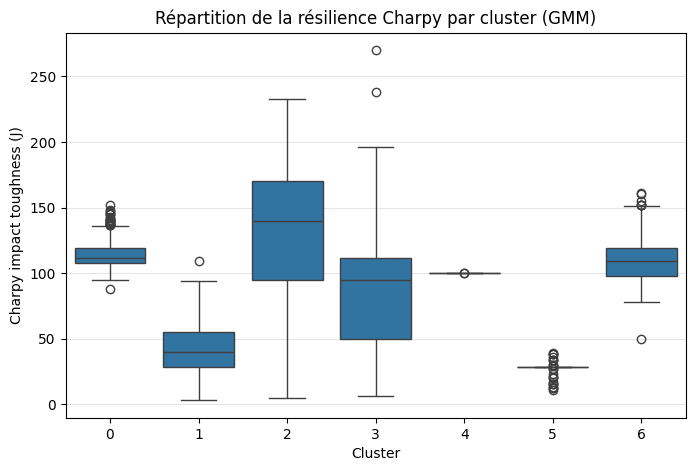

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_gmm,
    x="cluster_gmm",
    y="Charpy impact toughness (J)"
)
plt.title("Répartition de la résilience Charpy par cluster (GMM)")
plt.xlabel("Cluster")
plt.ylabel("Charpy impact toughness (J)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [ ]:
import numpy as np

max_proba = probas_gmm.max(axis=1)
df_gmm["cluster_proba"] = max_proba

borderline = df_gmm[df_gmm["cluster_proba"] < 0.7]
print("Nombre de points incertains :", len(borderline))
borderline.head()


Nombre de points incertains : 147


,Yield strength (MPa),Charpy impact toughness (J),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),cluster_gmm,cluster_proba
0,392.000000,144.823212,80.60000,31.90000,466.000000,0,0.480789
21,526.000000,100.496628,72.90000,26.80000,612.000000,2,0.590674
40,567.000000,109.093163,72.70000,23.60000,635.000000,6,0.618002
47,479.618622,100.000000,71.99646,31.07807,560.108276,4,0.525519
49,525.000000,137.678024,76.00000,27.60000,605.000000,0,0.638942


PCA + GMM


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape après PCA :", X_pca.shape)
print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)
print("Variance expliquée cumulée :", pca.explained_variance_ratio_.sum())


Shape après PCA : (1639, 2)
Variance expliquée par PC1 et PC2 : [0.77259311 0.14122847]
Variance expliquée cumulée : 0.9138215775212816


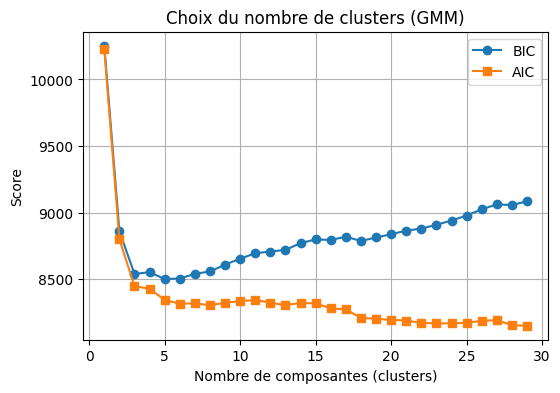

In [ ]:
n_components_range = range(1, 30)
bics = []
aics = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_pca)
    bics.append(gmm.bic(X_pca))
    aics.append(gmm.aic(X_pca))

plt.figure(figsize=(6, 4))
plt.plot(n_components_range, bics, marker="o", label="BIC")
plt.plot(n_components_range, aics, marker="s", label="AIC")
plt.xlabel("Nombre de composantes (clusters)")
plt.ylabel("Score")
plt.title("Choix du nombre de clusters (GMM)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_clusters = 3

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_pca)

# labels de cluster
labels_gmm = gmm.predict(X_pca)

# probabilités d’appartenance à chaque cluster
probas_gmm = gmm.predict_proba(X_pca)

# On crée un DataFrame combinant données originales + info clustering
df_pca_gmm = X.copy()
df_pca_gmm["PC1"] = X_pca[:, 0]
df_pca_gmm["PC2"] = X_pca[:, 1]
df_pca_gmm["cluster_gmm"] = labels_gmm
df_pca_gmm.head()


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),PC1,PC2,cluster_gmm
0,392.000000,80.600000,31.900000,466.000000,-2.466933,-0.053759,2
1,389.621704,80.177002,33.847198,469.341492,-2.643236,-0.074793,2
2,370.000000,80.600000,35.200000,456.000000,-3.001650,-0.165262,2
3,413.000000,80.600000,31.200000,498.000000,-2.074382,0.148931,2
4,416.176819,80.045105,32.911324,493.187958,-2.237376,0.116796,2


In [ ]:
# Taille de chaque cluster
print("Nombre de points par cluster :")
print(df_pca_gmm["cluster_gmm"].value_counts().sort_index())

# Moyenne des propriétés mécaniques par cluster
cluster_means = df_pca_gmm.groupby("cluster_gmm")[features].mean()
print("\nMoyennes des features par cluster :")
cluster_means


Nombre de points par cluster :
cluster_gmm
0    684
1     76
2    879
Name: count, dtype: int64

Moyennes des features par cluster :


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa)
cluster_gmm,,,,
0,550.190467,66.754214,23.157785,649.279143
1,547.268323,44.734672,19.974588,673.134854
2,459.743072,77.460704,29.036650,543.905039


In [ ]:
cluster_stats = df_pca_gmm.groupby("cluster_gmm")[features].agg(["mean", "std"])
cluster_stats


Yield strength (MPa)             Reduction of Area (%)             \
                            mean         std                  mean        std   
cluster_gmm                                                                     
0                     550.190467  100.851411             66.754214   5.014957   
1                     547.268323   75.333854             44.734672  10.803354   
2                     459.743072   50.002643             77.460704   1.914966   

            Elongation (%)           Ultimate tensile strength (MPa)  \
                      mean       std                            mean   
cluster_gmm                                                            
0                23.157785  4.472497                      649.279143   
1                19.974588  4.788228                      673.134854   
2                29.036650  2.763145                      543.905039   

                        
                   std  
cluster_gmm             
0            90.443090  
1            80.790879  
2            44.302975

# Ce que racontent les clusters, physiquement
**Cluster 1 :** forte résistance, ductilité faible → comportement plus fragile

Re ≈ 547 MPa, Rm ≈ 673 MPa : résistance élevée, c’est le plus haut Rm.

A ≈ 20 %, Réduction de section ≈ 45 % : ductilité nettement plus faible que les autres.

Std de Réduction de section assez élevée → comportement plus dispersé.

Interprétation possible :

Microstructure plus dure / plus fragile (martensite, bainite dure, soudage à refroidissement rapide, métaux d’apport plus résistants, etc.).

Potentiel risque de rupture fragile ou de fissuration, surtout si des défauts ou contraintes résiduelles sont présents.

 Physiquement : des soudures fortement résistantes mais moins tolérantes aux défauts.

**Cluster 0 :** compromis résistance / ductilité → “équilibré”

Re ≈ 550 MPa (similaire cluster 1), Rm ≈ 649 MPa : bonne résistance.

A ≈ 23 %, Réduction de section ≈ 67 % : ductilité intermédiaire.

Std modérés : population un peu hétérogène mais pas extrême.

Interprétation possible :

Microstructure mixte, ni trop dure ni trop molle (ferrite + perlite, bainite tempérée…).

Soudures qui gardent un bon niveau de résistance et une ductilité encore correcte.

 Physiquement : ce cluster ressemble à des soudures “saines” au bon compromis résistance / ductilité, souvent ce qu’on recherche en pratique si les valeurs sont conformes au cahier des charges.

**Cluster 2 :** résistance plus faible, ductilité élevée → matériau plus “mou” mais tenace

Re ≈ 460 MPa, Rm ≈ 544 MPa : clairement les plus faibles résistances.

A ≈ 29 %, Réduction de section ≈ 77 % : meilleure ductilité de loin.

Std très faibles sur A et Réduction de section → comportement très homogène.

Interprétation possible :

Microstructure plus ferritique / plus recuite, moins durcie.

Soudure “sous-durcie” ou zone affectée thermiquement douce, voire légers défauts de résistance mais très bonne capacité de déformation avant rupture.

 Physiquement : soudures très ductiles mais moins résistantes, potentiellement tolérantes aux défauts mais limitantes si des valeurs minimales de Re/Rm sont exigées.

**il y a une signification physique probable :**

un cluster plus dur/fragile (1),

un plus équilibré (0),

un plus doux/ductile (2).

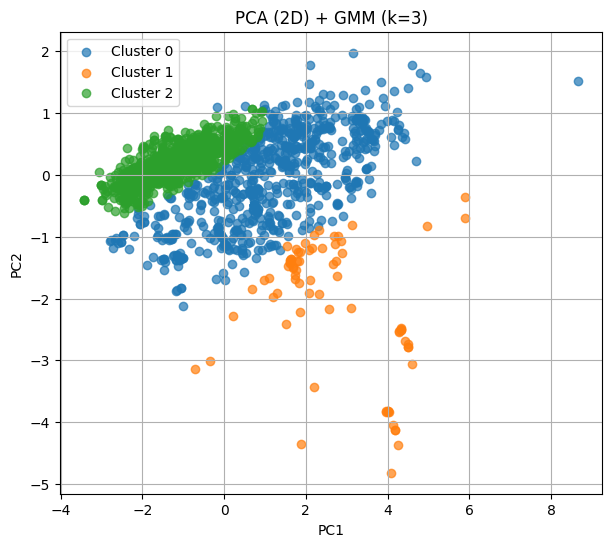

In [ ]:
plt.figure(figsize=(7, 6))

for c in range(n_clusters):
    subset = df_pca_gmm[df_pca_gmm["cluster_gmm"] == c]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) + GMM (k=3)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
max_proba = probas_gmm.max(axis=1)
df_pca_gmm["cluster_proba"] = max_proba

borderline = df_pca_gmm[df_pca_gmm["cluster_proba"] < 0.65]

print("Nombre de points avec proba < 0.7 pour leur cluster :", len(borderline))
borderline.head()


Nombre de points avec proba < 0.7 pour leur cluster : 86


,Yield strength (MPa),Reduction of Area (%),Elongation (%),Ultimate tensile strength (MPa),PC1,PC2,cluster_gmm,cluster_proba
40,567.000000,72.700000,23.600000,635.000000,0.843583,0.560517,0,0.599234
44,565.606750,72.785858,24.666185,649.049988,0.806317,0.616479,2,0.492368
47,479.618622,71.996460,31.078070,560.108276,-0.874429,-0.118662,2,0.635010
52,621.000000,72.900000,25.400000,682.000000,1.250182,1.029373,0,0.636304
53,606.592041,71.638077,26.099575,687.941223,1.190577,0.860663,0,0.607105


In [ ]:
borderline["cluster_gmm"].value_counts().sort_index()


,count
cluster_gmm,
0,47
1,5
2,34


In [ ]:
sure = df_pca_gmm[df_pca_gmm["cluster_proba"] >= 0.7]

print("Taille sure :", len(sure))
print("Taille borderline :", len(borderline))


Taille sure : 1523
Taille borderline : 86


In [ ]:
print("Moyennes des features pour les points sûrs :")
print(sure[features].mean())

print("\nMoyennes des features pour les points borderline :")
print(borderline[features].mean())


Moyennes des features pour les points sûrs :
Yield strength (MPa)               499.194911
Reduction of Area (%)               71.598627
Elongation (%)                      26.253425
Ultimate tensile strength (MPa)    591.945940
dtype: float64

Moyennes des features pour les points borderline :
Yield strength (MPa)               535.863147
Reduction of Area (%)               69.867901
Elongation (%)                      25.400844
Ultimate tensile strength (MPa)    620.359366
dtype: float64


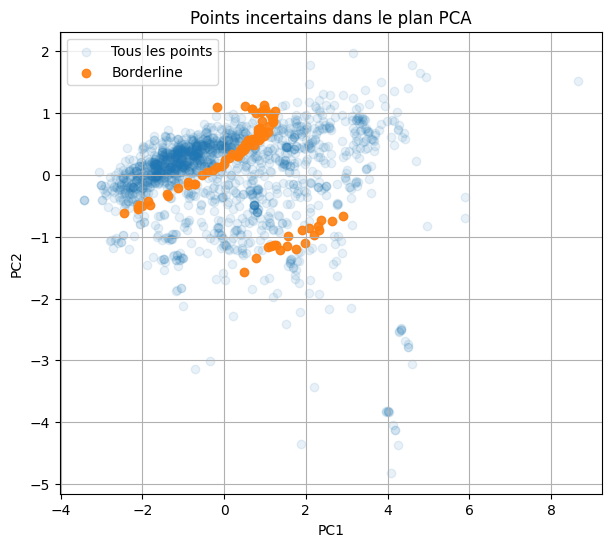

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(df_pca_gmm["PC1"], df_pca_gmm["PC2"], alpha=0.1, label="Tous les points")
plt.scatter(borderline["PC1"], borderline["PC2"], alpha=0.9, label="Borderline")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Points incertains dans le plan PCA")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

df["cluster_gmm"] = np.nan
df["cluster_proba"] = np.nan

df.loc[X.index, "cluster_gmm"] = labels_gmm
df.loc[X.index, "cluster_proba"] = probas_gmm.max(axis=1)


In [ ]:
df.to_csv("data_avec_clusters.csv", index=False)


In [ ]:
df['cluster_gmm'].value_counts()

,count
cluster_gmm,
0.0,758
4.0,274
3.0,176
2.0,154
1.0,149
5.0,128


C'est avec ces trois clusters qu'on va travailler après ...